Loaded 11,788 rows from csv\image_statistic.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_23228\1493450393.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", top_n)


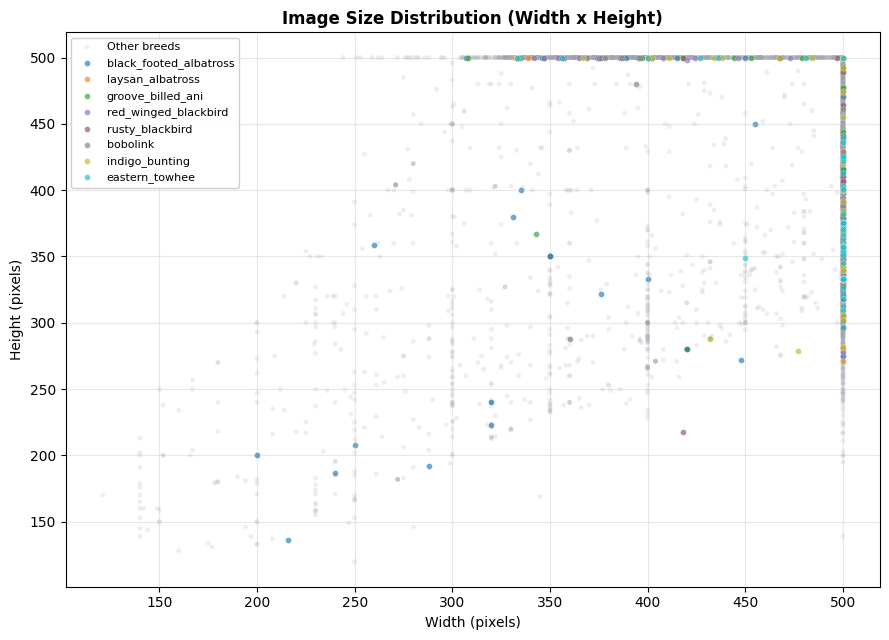

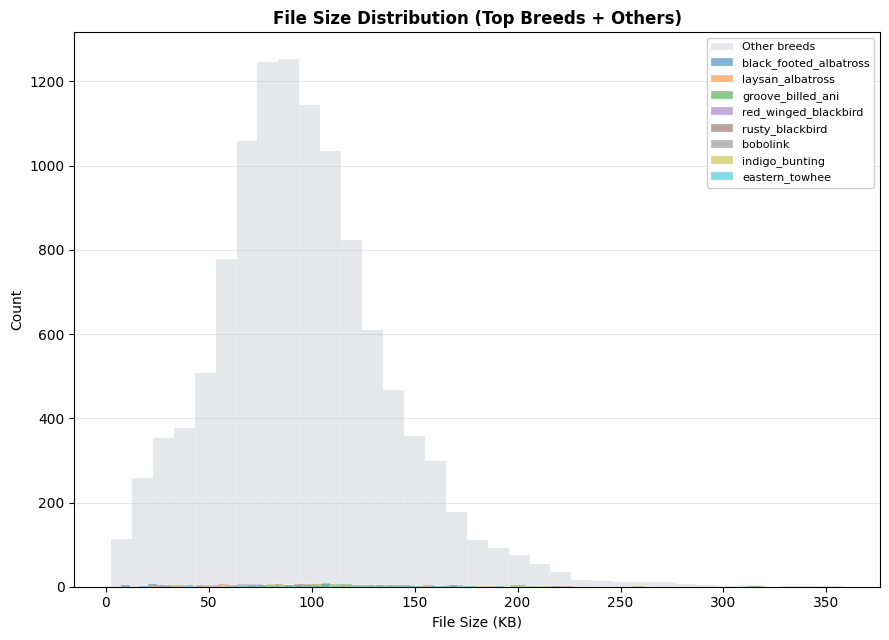

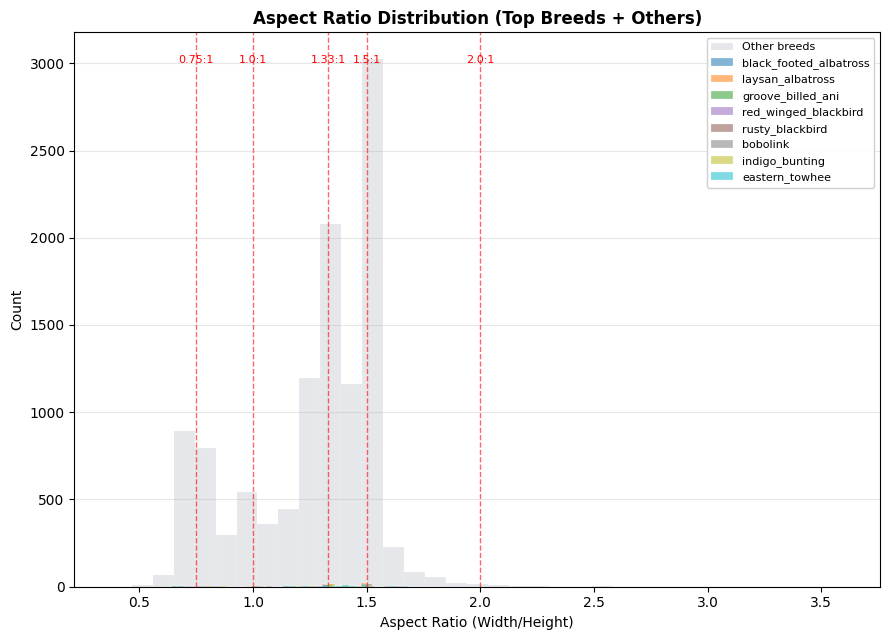


Quick stats
Total images: 11,788
Total breeds: 200
Mean width:   467.9 px
Mean height:  386.0 px
Mean file size: 95.3 KB
Mean ratio:   1.257
Median ratio: 1.333

Top 10 breeds by image count:
  black_footed_albatross: 60
  laysan_albatross: 60
  groove_billed_ani: 60
  red_winged_blackbird: 60
  rusty_blackbird: 60
  bobolink: 60
  indigo_bunting: 60
  eastern_towhee: 60
  pelagic_cormorant: 60
  bronzed_cowbird: 60


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# 1) Load local CSV
csv_path = Path("csv/image_statistic.csv")
if not csv_path.exists():
    raise FileNotFoundError("Could not find csv data")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from {csv_path}")

required_cols = ["width", "height", "breed"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Create aspect_ratio if needed
if "aspect_ratio" not in df.columns:
    df["aspect_ratio"] = df["width"] / df["height"].replace(0, np.nan)

# Normalize file size to KB using available dataset attributes
if "file_size_kb" not in df.columns:
    if "file_size_bytes" in df.columns:
        df["file_size_kb"] = df["file_size_bytes"] / 1024.0
    elif "file_size_by" in df.columns:
        df["file_size_kb"] = df["file_size_by"] / 1024.0
    else:
        df["file_size_kb"] = np.nan

df = df.dropna(subset=["width", "height", "aspect_ratio", "breed"])

# Use top breeds to keep charts readable
top_n = 8
top_breeds = df["breed"].value_counts().head(top_n).index.tolist()
color_map = plt.cm.get_cmap("tab10", top_n)
breed_colors = {breed: color_map(i) for i, breed in enumerate(top_breeds)}

# 2) Plot charts as separate figures (instead of one large combined image)

# Chart A: Image Size Distribution (Width vs Height)
fig1, ax1 = plt.subplots(figsize=(9, 6.5))
others = df[~df["breed"].isin(top_breeds)]
if len(others) > 0:
    ax1.scatter(
        others["width"],
        others["height"],
        s=12,
        alpha=0.18,
        c="#9ca3af",
        edgecolors="none",
        label="Other breeds",
    )

for breed in top_breeds:
    block = df[df["breed"] == breed]
    ax1.scatter(
        block["width"],
        block["height"],
        s=18,
        alpha=0.65,
        c=[breed_colors[breed]],
        edgecolors="white",
        linewidths=0.25,
        label=breed,
    )

ax1.set_title("Image Size Distribution (Width x Height)", fontweight="bold")
ax1.set_xlabel("Width (pixels)")
ax1.set_ylabel("Height (pixels)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left", fontsize=8, framealpha=0.92)
plt.tight_layout()
plt.show()

# Chart B: File Size Distribution
fig2, ax2 = plt.subplots(figsize=(9, 6.5))
file_size_data = df.dropna(subset=["file_size_kb"])
if len(file_size_data) == 0:
    ax2.text(0.5, 0.5, "file_size_kb not available", ha="center", va="center", fontsize=11)
    ax2.set_axis_off()
else:
    others_size = file_size_data[~file_size_data["breed"].isin(top_breeds)]
    if len(others_size) > 0:
        ax2.hist(
            others_size["file_size_kb"],
            bins=35,
            alpha=0.25,
            color="#9ca3af",
            edgecolor="white",
            linewidth=0.3,
            label="Other breeds",
        )

    for breed in top_breeds:
        block = file_size_data[file_size_data["breed"] == breed]
        ax2.hist(
            block["file_size_kb"],
            bins=35,
            alpha=0.55,
            color=breed_colors[breed],
            edgecolor="white",
            linewidth=0.3,
            label=breed,
        )

    ax2.set_title("File Size Distribution (Top Breeds + Others)", fontweight="bold")
    ax2.set_xlabel("File Size (KB)")
    ax2.set_ylabel("Count")
    ax2.grid(True, axis="y", alpha=0.3)
    ax2.legend(fontsize=8, framealpha=0.92)

plt.tight_layout()
plt.show()

# Chart C: Aspect Ratio Distribution
fig3, ax3 = plt.subplots(figsize=(9, 6.5))
others_ratio = df[~df["breed"].isin(top_breeds)]
if len(others_ratio) > 0:
    ax3.hist(
        others_ratio["aspect_ratio"],
        bins=35,
        alpha=0.25,
        color="#9ca3af",
        edgecolor="white",
        linewidth=0.3,
        label="Other breeds",
    )

for breed in top_breeds:
    block = df[df["breed"] == breed]
    ax3.hist(
        block["aspect_ratio"],
        bins=35,
        alpha=0.55,
        color=breed_colors[breed],
        edgecolor="white",
        linewidth=0.3,
        label=breed,
    )

common_ratios = [0.75, 1.0, 1.33, 1.5, 2.0]
for r in common_ratios:
    ax3.axvline(r, color="red", linestyle="--", linewidth=1, alpha=0.6)

ymax = ax3.get_ylim()[1]
for r in common_ratios:
    ax3.text(r, ymax * 0.96, f"{r}:1", color="red", fontsize=8, ha="center", va="top")

ax3.set_title("Aspect Ratio Distribution (Top Breeds + Others)", fontweight="bold")
ax3.set_xlabel("Aspect Ratio (Width/Height)")
ax3.set_ylabel("Count")
ax3.grid(True, axis="y", alpha=0.3)
ax3.legend(fontsize=8, framealpha=0.92)
plt.tight_layout()
plt.show()

print("\nQuick stats")
print(f"Total images: {len(df):,}")
print(f"Total breeds: {df['breed'].nunique():,}")
print(f"Mean width:   {df['width'].mean():.1f} px")
print(f"Mean height:  {df['height'].mean():.1f} px")
if len(file_size_data) > 0:
    print(f"Mean file size: {file_size_data['file_size_kb'].mean():.1f} KB")
print(f"Mean ratio:   {df['aspect_ratio'].mean():.3f}")
print(f"Median ratio: {df['aspect_ratio'].median():.3f}")

print("\nTop 10 breeds by image count:")
for name, count in df['breed'].value_counts().head(10).items():
    print(f"  {name}: {count}")

Loaded 11,788 rows from csv\image_statistic.csv


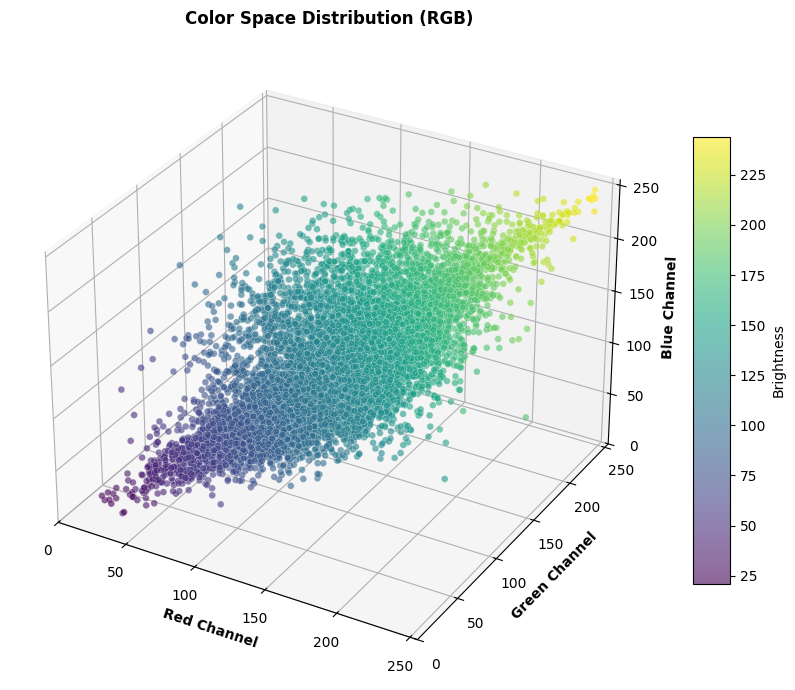

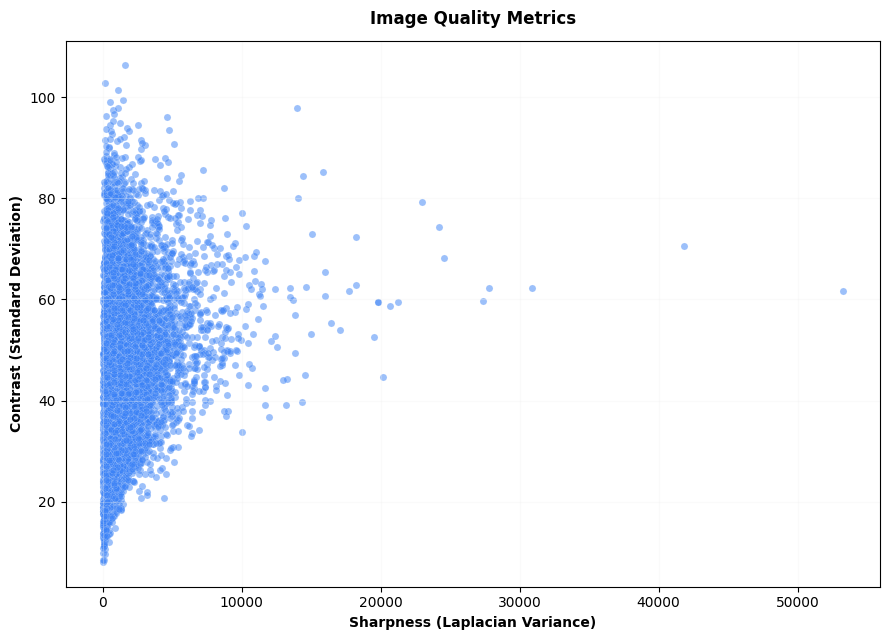

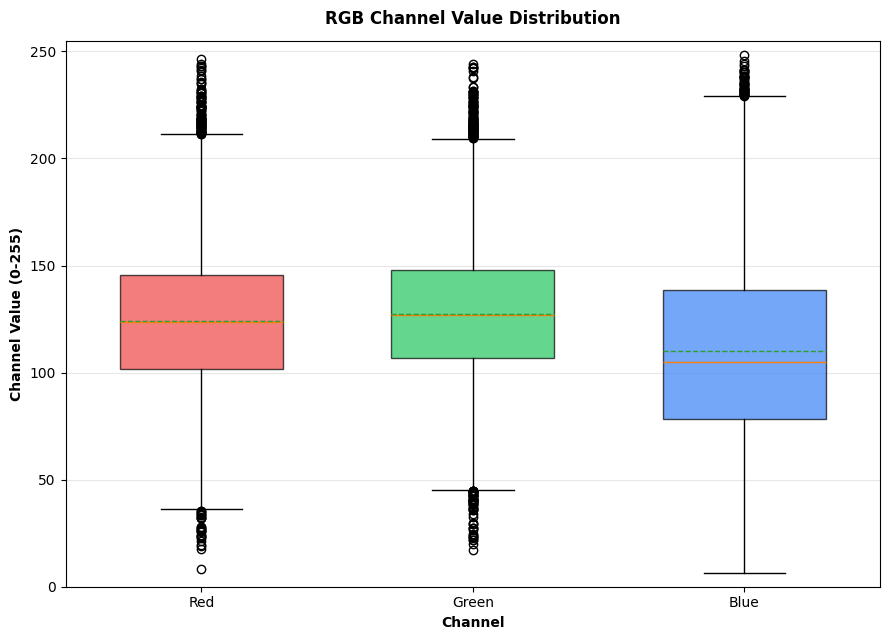

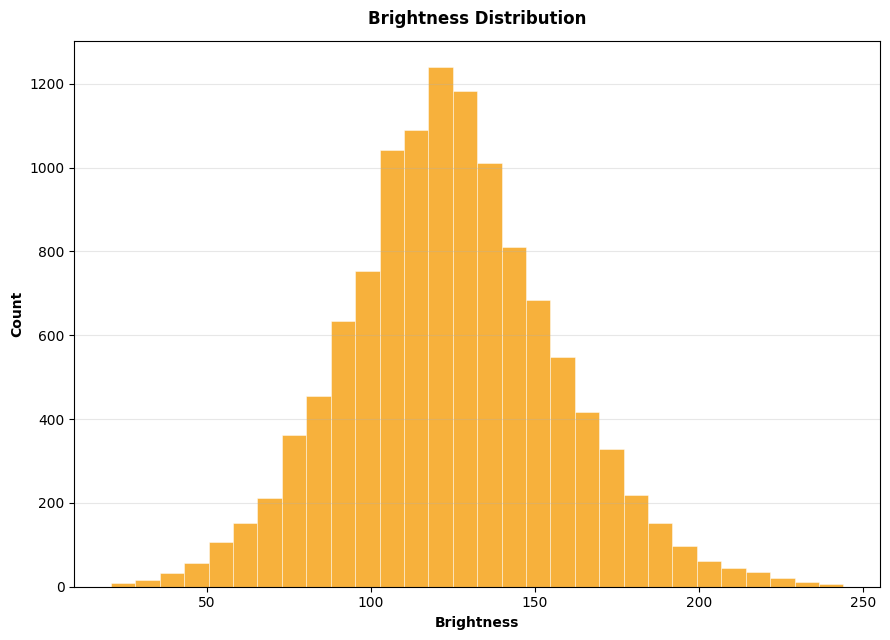

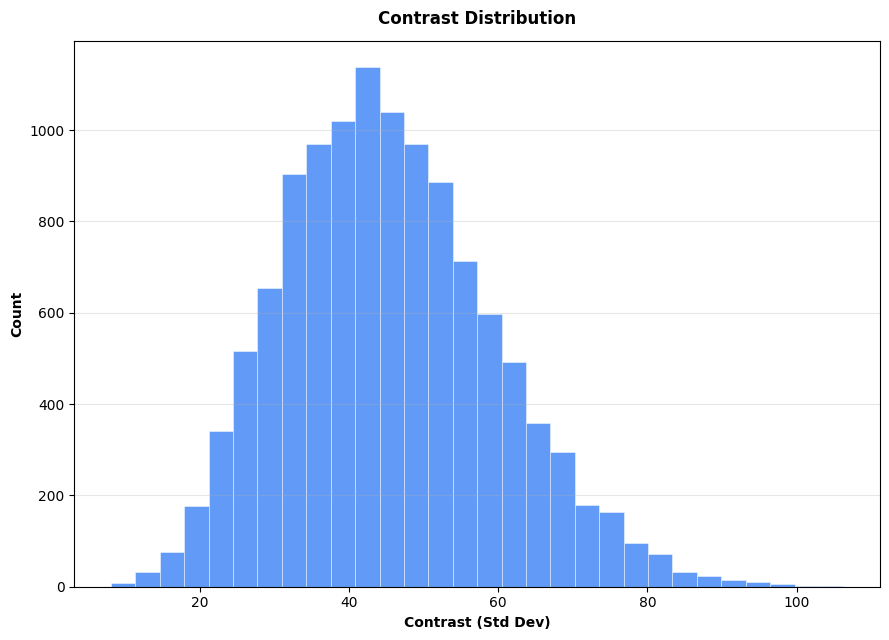


CUB COLOR STATISTICS SUMMARY
Rows used: 11,788
Red mean:   123.9 | std: 33.8
Green mean: 127.4 | std: 32.1
Blue mean:  110.1 | std: 43.7
Brightness: 124.4 (+/-32.0)
Contrast:   45.4 (+/-14.1)
Sharpness:  1375.2 (+/-1866.2)


In [3]:
"""
Part 2: Core EDA - Color Space Analysis & Quality Metrics (CUB, no split)
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# 1) Load local CSV
csv_path = Path("csv/image_statistic.csv")
if not csv_path.exists():
    raise FileNotFoundError("Could not find csv data")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from {csv_path}")

required_cols = [
    "mean_r", "mean_g", "mean_b",
    "brightness", "contrast", "sharpness",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

has_breed = "breed" in df.columns
df_plot = df.dropna(subset=required_cols).copy()

# Chart 1: 3D Color Space Distribution (RGB)
fig1 = plt.figure(figsize=(9, 7))
ax1 = fig1.add_subplot(1, 1, 1, projection="3d")
scatter = ax1.scatter(
    df_plot["mean_r"],
    df_plot["mean_g"],
    df_plot["mean_b"],
    c=df_plot["brightness"],
    cmap="viridis",
    s=24,
    alpha=0.6,
    edgecolors="white",
    linewidths=0.25,
)
ax1.set_xlabel("Red Channel", fontsize=10, fontweight="bold")
ax1.set_ylabel("Green Channel", fontsize=10, fontweight="bold")
ax1.set_zlabel("Blue Channel", fontsize=10, fontweight="bold")
ax1.set_title("Color Space Distribution (RGB)", fontsize=12, fontweight="bold", pad=12)
ax1.set_xlim(0, 255)
ax1.set_ylim(0, 255)
ax1.set_zlim(0, 255)
cbar1 = plt.colorbar(scatter, ax=ax1, shrink=0.7, aspect=12)
cbar1.set_label("Brightness", fontsize=10)
plt.tight_layout()
plt.show()

# Chart 2: Image Quality Metrics (Sharpness vs Contrast)
fig2, ax2 = plt.subplots(figsize=(9, 6.5))
ax2.scatter(
    df_plot["sharpness"],
    df_plot["contrast"],
    c="#3b82f6",
    s=26,
    alpha=0.5,
    edgecolors="white",
    linewidths=0.2,
)
ax2.set_xlabel("Sharpness (Laplacian Variance)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Contrast (Standard Deviation)", fontsize=10, fontweight="bold")
ax2.set_title("Image Quality Metrics", fontsize=12, fontweight="bold", pad=12)
ax2.grid(True, alpha=0.3, color="#f0f0f0")
plt.tight_layout()
plt.show()

# Chart 3: RGB Channel Distribution (Box Plots)
fig3, ax3 = plt.subplots(figsize=(9, 6.5))
channel_data = [df_plot["mean_r"], df_plot["mean_g"], df_plot["mean_b"]]
channel_labels = ["Red", "Green", "Blue"]
channel_colors = ["#ef4444", "#22c55e", "#3b82f6"]

bp = ax3.boxplot(
    channel_data,
    tick_labels=channel_labels,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    widths=0.6,
)
for patch, color in zip(bp["boxes"], channel_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel("Channel Value (0-255)", fontsize=10, fontweight="bold")
ax3.set_xlabel("Channel", fontsize=10, fontweight="bold")
ax3.set_title("RGB Channel Value Distribution", fontsize=12, fontweight="bold", pad=12)
ax3.set_ylim(0, 255)
ax3.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Chart 4: Brightness Distribution
fig4, ax4 = plt.subplots(figsize=(9, 6.5))
ax4.hist(
    df_plot["brightness"],
    bins=30,
    alpha=0.8,
    color="#f59e0b",
    edgecolor="white",
    linewidth=0.4,
)
ax4.set_xlabel("Brightness", fontsize=10, fontweight="bold")
ax4.set_ylabel("Count", fontsize=10, fontweight="bold")
ax4.set_title("Brightness Distribution", fontsize=12, fontweight="bold", pad=12)
ax4.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Chart 5: Contrast Distribution
fig5, ax5 = plt.subplots(figsize=(9, 6.5))
ax5.hist(
    df_plot["contrast"],
    bins=30,
    alpha=0.8,
    color="#3b82f6",
    edgecolor="white",
    linewidth=0.4,
)
ax5.set_xlabel("Contrast (Std Dev)", fontsize=10, fontweight="bold")
ax5.set_ylabel("Count", fontsize=10, fontweight="bold")
ax5.set_title("Contrast Distribution", fontsize=12, fontweight="bold", pad=12)
ax5.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CUB COLOR STATISTICS SUMMARY")
print("=" * 70)
print(f"Rows used: {len(df_plot):,}")
print(f"Red mean:   {df_plot['mean_r'].mean():.1f} | std: {df_plot['mean_r'].std():.1f}")
print(f"Green mean: {df_plot['mean_g'].mean():.1f} | std: {df_plot['mean_g'].std():.1f}")
print(f"Blue mean:  {df_plot['mean_b'].mean():.1f} | std: {df_plot['mean_b'].std():.1f}")
print(f"Brightness: {df_plot['brightness'].mean():.1f} (+/-{df_plot['brightness'].std():.1f})")
print(f"Contrast:   {df_plot['contrast'].mean():.1f} (+/-{df_plot['contrast'].std():.1f})")
print(f"Sharpness:  {df_plot['sharpness'].mean():.1f} (+/-{df_plot['sharpness'].std():.1f})")

## Final Findings - Part 1 and Part 2 (CUB)

### Part 1: Image Size, File Size, and Aspect Ratio

1. **Image dimensions vary, but within practical limits**
- Width and height are spread across a moderate range, with many samples near common resize boundaries.
- This indicates natural diversity with some implicit size constraints from data collection or preprocessing.

2. **Aspect ratio distribution is concentrated**
- Most images fall near common photo ratios (roughly around 1.0 to 1.5).
- Extreme aspect-ratio outliers exist but are uncommon.

3. **File size is right-skewed**
- Most samples are small-to-medium files.
- A smaller long tail of larger files suggests variation in detail level and compression characteristics.

4. **Breed-level coverage appears balanced at a high level**
- Top breeds show similar image counts in this processed table.
- Severe class-count imbalance is not obvious from this first pass.

### Part 2: Color Space and Quality Metrics

1. **RGB channel behavior is stable and natural**
- Mean channel values stay in realistic ranges, with green generally slightly higher and blue somewhat lower on average.
- Boxplots show broad but coherent channel distributions, without severe clipping.

2. **Brightness and contrast are centered with moderate spread**
- Brightness and contrast histograms are unimodal and reasonably compact.
- The dataset contains variability, but not heavy multimodal shifts that would indicate major domain mixing.

3. **Sharpness has a heavy tail**
- Most images have moderate sharpness, with fewer very high-sharpness outliers.
- This is typical of mixed focus quality and texture complexity across natural bird photos.

4. **Overall data quality profile is suitable for classification pipelines**
- Combined color and quality metrics suggest the dataset is diverse enough for learning while still statistically consistent.
- Standard normalization and augmentation should be effective without needing aggressive corrective filtering.

### Overall Conclusion

The first two EDA parts indicate a **well-structured CUB image dataset** with manageable geometric variation, stable color statistics, and realistic quality diversity. This supports moving forward to feature extraction and model training with confidence, while keeping lightweight outlier-aware preprocessing in place.